## CUDA

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


## Only CPU

In [3]:
!pip install torch torchvision

In [41]:
!pip install optuna
!pip install thop

  Obtaining dependency information for thop from https://files.pythonhosted.org/packages/bb/0f/72beeab4ff5221dc47127c80f8834b4bcd0cb36f6ba91c0b1d04a1233403/thop-0.1.1.post2209072238-py3-none-any.whl.metadata


In [44]:
import torch
import torchvision

print("✅ PyTorch version:", torch.__version__)
print("✅ Torchvision version:", torchvision.__version__)
print("✅ CUDA acceleration available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("🛸 Active GPU Device:", torch.cuda.get_device_name(0))

✅ PyTorch version: 2.5.1+cu121
✅ Torchvision version: 0.20.1+cu121
✅ CUDA acceleration available: True
🛸 Active GPU Device: NVIDIA GeForce RTX 2080 SUPER


In [45]:
import os

DATASET_PATH = "dataset/PCB_DATASET"

# --- 1. File System Overview ---
print(f"\n[SECTION 1] Directory Inspection: {DATASET_PATH}")
print("-" * 40)
count = 0
for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        # if count < 10:  # Show first 10 files as examples
        #     print(f"Found: {os.path.join(root, file)}")
        #     count += 1
        print(f"Found: {os.path.join(root, file)}")
if count == 0:
    print("Warning: No files found. Please check your path.")


[SECTION 1] Directory Inspection: dataset/PCB_DATASET
----------------------------------------
Found: dataset/PCB_DATASET\rotate.py
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_01.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_02.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_03.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_04.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_05.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_06.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_07.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_08.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_09.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_10.xml
Found: dataset/PCB_DATASET\Annotations\Missing_hole\01_missing_hole_11.xml
Found: dataset/PCB_DATASET\Annotations\Mis

## Import & Parameter

In [46]:
import os
import cv2
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

# Ensure scikit-image is available for SSIM-NET simulation
try:
    from skimage.metrics import structural_similarity as ssim
except ImportError:
    # Fallback message to assist in setting up the environment
    raise ImportError("Please install scikit-image using: pip install scikit-image")

# Set up global parameters for comparison algorithm input requirements
TARGET_SIZE = (224, 224) # Standard input size for LPViT, ResNet, MobileNet, and AlexNet
PIXELS_PER_MM = 15.0     # Default spatial calibration factor

print("✅ Initialization complete. Target patch dimension set to:", TARGET_SIZE)

✅ Initialization complete. Target patch dimension set to: (224, 224)


## Data Augmentation Module

In [47]:
import os
import random
import shutil
import cv2
import datetime
import numpy as np
import xml.etree.ElementTree as ET
from pathlib import Path
from IPython.display import display, Image
from tqdm.notebook import tqdm

# ==============================================================================
# 0. CORE HELPERS
# ==============================================================================
LOG_FILE_PATH = "experiment_results_log.txt"
VISUAL_LOG_DIR = "log"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    cv2.setRNGSeed(seed)

def log_message(message):
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    formatted_msg = f"[{timestamp}] {message}"
    print(message)
    with open(LOG_FILE_PATH, "a", encoding="utf-8") as f:
        f.write(formatted_msg + "\n")

def transform_coords(xmin, ymin, xmax, ymax, h, w, jitter_range=None):
    """Calculates new coordinates by applying random BBox Jitter offset."""
    if jitter_range:
        # Ref: Huang & Wei, 2019 - Spatial offset to bounding-box coordinates
        off_x = random.randint(jitter_range[0], jitter_range[1]) * random.choice([-1, 1])
        off_y = random.randint(jitter_range[0], jitter_range[1]) * random.choice([-1, 1])
        xmin, ymin = max(0, xmin + off_x), max(0, ymin + off_y)
        xmax, ymax = min(w, xmax + off_x), min(h, ymax + off_y)
        
    return int(xmin), int(ymin), int(xmax), int(ymax)

# ==============================================================================
# 1. CORE TRANSFORMATIONS
# ==============================================================================

def add_gaussian_noise(image, sigma=20):
    """Ref: Ding et al., 2019 - Simulating industrial camera sensor noise."""
    gauss = np.random.normal(0, sigma, image.shape).astype('float32')
    return np.clip(image.astype('float32') + gauss, 0, 255).astype('uint8')

def rotate_bbox_only(image, xml_path, angle, target_classes=['Mouse_bite', 'Missing_hole']):
    """Object-level: Rotates only the defect ROI area."""
    if not (xml_path and Path(xml_path).exists()): return image
    root = ET.parse(str(xml_path)).getroot()
    rotated_image = image.copy()
    h_img, w_img = image.shape[:2]
    targets = [c.lower() for c in target_classes]
    
    for obj in root.findall('object'):
        if obj.find('name').text.lower() in targets:
            b = obj.find('bndbox')
            x1, y1, x2, y2 = int(float(b.find('xmin').text)), int(float(b.find('ymin').text)), int(float(b.find('xmax').text)), int(float(b.find('ymax').text))
            x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w_img, x2), min(h_img, y2)
            roi_w, roi_h = x2 - x1, y2 - y1
            if roi_w <= 0 or roi_h <= 0: continue
            M = cv2.getRotationMatrix2D((roi_w/2, roi_h/2), angle, 1.0)
            rotated_image[y1:y2, x1:x2] = cv2.warpAffine(image[y1:y2, x1:x2], M, (roi_w, roi_h), borderMode=cv2.BORDER_REFLECT)
    return rotated_image

# ==============================================================================
# 2. PREVIEW & VISUALIZATION (4-COLUMN GRID)
# ==============================================================================

def calculate_resized_dimensions(h, w, max_dim):
    scale = max_dim / max(h, w)
    return (int(w * scale), int(h * scale)), scale

def preview_augmentation(
    image_dir, annotation_dir,
    sigma_val=25, angle_val=12, jitter_range=(8, 8),
    preview_zoom_padding=120, seed=42
):
    set_seed(seed)
    img_path_obj, ann_path_obj = Path(image_dir), Path(annotation_dir)
    image_paths = sorted([p for p in img_path_obj.rglob('*') if p.suffix.lower() in ('.jpg', '.png')])
    
    # Try to find a target class for a better preview
    target_paths = [p for p in image_paths if p.parent.name.lower() in ['mouse_bite', 'missing_hole']]
    sample_path = random.choice(target_paths) if target_paths else random.choice(image_paths)
    xml_path = ann_path_obj / sample_path.relative_to(img_path_obj).parent / f"{sample_path.stem}.xml"

    img_bgr = cv2.imread(str(sample_path))
    h, w = img_bgr.shape[:2]

    # --- Generate Versions ---
    aug_noisy = add_gaussian_noise(img_bgr, sigma=sigma_val)
    aug_roi_rot = rotate_bbox_only(img_bgr, xml_path, angle=angle_val)

    # --- Draw Boxes for Global View ---
    dim_g, scale_g = calculate_resized_dimensions(h, w, max_dim=500)
    
    def get_global(src, jitter=None):
        canvas = cv2.resize(src, dim_g)
        root = ET.parse(str(xml_path)).getroot()
        for obj in root.findall('object'):
            b = obj.find('bndbox')
            nx1, ny1, nx2, ny2 = transform_coords(float(b.find('xmin').text), float(b.find('ymin').text), 
                                                 float(b.find('xmax').text), float(b.find('ymax').text), 
                                                 h, w, jitter_range=jitter)
            cv2.rectangle(canvas, (int(nx1*scale_g), int(ny1*scale_g)), (int(nx2*scale_g), int(ny2*scale_g)), (0,255,0), 2)
        return canvas

    g_orig = get_global(img_bgr)
    g_noise = get_global(aug_noisy)
    g_jitter = get_global(img_bgr, jitter=jitter_range)
    g_roi = get_global(aug_roi_rot)

    # --- Zoomed Close-up View ---
    root = ET.parse(str(xml_path)).getroot()
    b = root.find('object').find('bndbox')
    ox1, oy1, ox2, oy2 = float(b.find('xmin').text), float(b.find('ymin').text), float(b.find('xmax').text), float(b.find('ymax').text)

    def get_zoom(src, jitter=None):
        zx1, zy1, zx2, zy2 = transform_coords(ox1, oy1, ox2, oy2, h, w, jitter)
        cx1, cy1 = max(0, zx1-preview_zoom_padding), max(0, zy1-preview_zoom_padding)
        cx2, cy2 = min(w, zx2+preview_zoom_padding), min(h, zy2+preview_zoom_padding)
        crop = src[int(cy1):int(cy2), int(cx1):int(cx2)].copy()
        rx1, ry1, rx2, ry2 = zx1-cx1, zy1-cy1, zx2-cx1, zy2-cy1
        cv2.rectangle(crop, (int(rx1), int(ry1)), (int(rx2), int(ry2)), (0, 255, 0), 3)
        return cv2.resize(crop, (400, 400))

    z_orig = get_zoom(img_bgr)
    z_noise = get_zoom(aug_noisy)
    z_jitter = get_zoom(img_bgr, jitter=jitter_range)
    z_roi = get_zoom(aug_roi_rot)

    # Combine grids
    grid_g = np.hstack([g_orig, g_noise, g_jitter, g_roi])
    labels = ["Original", "Gaussian Noise", "BBox Jitter", "ROI Rotated"]
    for i, txt in enumerate(labels): cv2.putText(grid_g, txt, (10 + i*dim_g[0], 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)
    
    grid_z = np.hstack([z_orig, z_noise, z_jitter, z_roi])
    
    display(Image(data=cv2.imencode('.jpg', grid_g)[1].tobytes()))
    display(Image(data=cv2.imencode('.jpg', grid_z)[1].tobytes()))

# ==============================================================================
# 3. BATCH AUGMENTATION
# ==============================================================================

def augment_dataset(
    image_dir, 
    annotation_dir, 
    output_img_dir, 
    output_xml_dir, 
    sample_ratio=0.8,
    sigma_range=(15, 25), 
    angle_range=(-15, 15),
    jitter_range=(5, 10),      # Ref: Huang & Wei (2019)
    seed=42
):
    """
    Performs the full industrial pipeline: 
    Augment (Rotation/Noise) -> Preprocess (Bilateral/CLAHE) -> Save with Jittered XML.
    """
    if seed is not None:
        set_seed(seed)

    img_path_obj = Path(image_dir)
    ann_path_obj = Path(annotation_dir)
    out_img_obj = Path(output_img_dir)
    out_xml_obj = Path(output_xml_dir)

    # Gather image list
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    image_paths = sorted([p for p in img_path_obj.rglob('*') if p.suffix.lower() in valid_extensions])

    if not image_paths:
        log_message(f"⚠️ No images found in: {image_dir}")
        return

    num_to_augment = int(len(image_paths) * sample_ratio)
    selected_images = random.sample(image_paths, num_to_augment)

    log_message("\n" + "=" * 65)
    log_message("🚀 DATA AUGMENTATION & PREPROCESSING STARTED")
    log_message(f"   -> Sequence: Augment -> Preprocess (Bilateral + CLAHE)")
    log_message(f"   -> Target: {num_to_augment} images ({sample_ratio*100}%)")
    log_message("=" * 65)

    for img_path in tqdm(selected_images, desc="Processing"):
        rel_path = img_path.relative_to(img_path_obj)
        xml_path = ann_path_obj / rel_path.parent / f"{img_path.stem}.xml"

        img = cv2.imread(str(img_path))
        if img is None: continue
        h, w = img.shape[:2]

        # --- STEP 1: AUGMENTATION (ROI ROTATION) ---
        aug_img = img.copy()
        is_target = rel_path.parent.name.lower() in ["missing_hole", "mouse_bite"]
        if is_target:
            angle = random.uniform(*angle_range)
            aug_img = rotate_bbox_only(aug_img, xml_path, angle=angle)

        # --- STEP 2: AUGMENTATION (GAUSSIAN NOISE) ---
        sigma = random.randint(*sigma_range)
        aug_img = add_gaussian_noise(aug_img, sigma=sigma)

        # --- STEP 3: PREPROCESSING (BILATERAL + CLAHE) ---
        # We clean the augmented/noisy image before saving
        final_img = preprocess_pcb_image(aug_img)

        # --- STEP 4: PREPARE PATHS & NAMES ---
        save_name = f"{img_path.stem}_aug_final"
        target_img_folder = out_img_obj / rel_path.parent
        target_xml_folder = out_xml_obj / rel_path.parent
        target_img_folder.mkdir(parents=True, exist_ok=True)
        target_xml_folder.mkdir(parents=True, exist_ok=True)

        # Save Image
        cv2.imwrite(str(target_img_folder / f"{save_name}{img_path.suffix}"), final_img)

        # --- STEP 5: SAVE XML WITH BBOX JITTER ---
        if xml_path.exists():
            tree = ET.parse(xml_path)
            root = tree.getroot()
            for obj in root.findall('object'):
                b = obj.find('bndbox')
                # Apply 5-10px spatial offset (Huang & Wei, 2019)
                nx1, ny1, nx2, ny2 = transform_coords(
                    float(b.find('xmin').text), float(b.find('ymin').text),
                    float(b.find('xmax').text), float(b.find('ymax').text),
                    h, w, jitter_range=jitter_range
                )
                b.find('xmin').text, b.find('ymin').text = str(nx1), str(ny1)
                b.find('xmax').text, b.find('ymax').text = str(nx2), str(ny2)
            tree.write(target_xml_folder / f"{save_name}.xml")

    log_message(f"✅ SUCCESSFULLY GENERATED {num_to_augment} PREPROCESSED SAMPLES.")


## Preview Augmentation

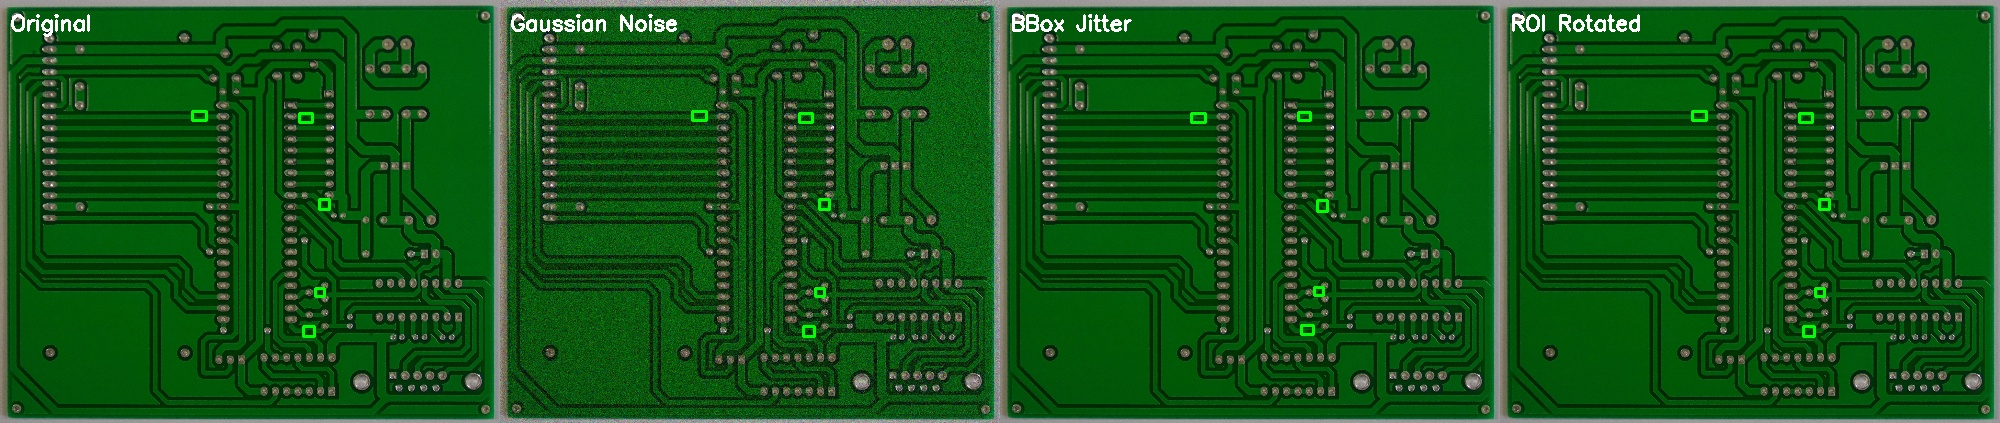

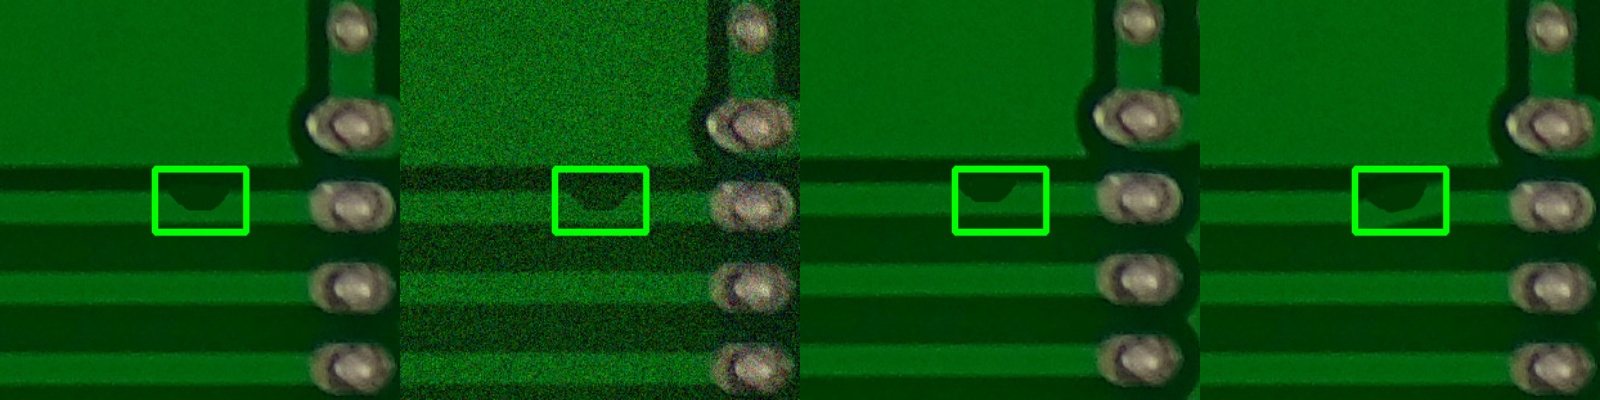

In [48]:
# ==============================================================================
# EXECUTION
# ==============================================================================
preview_augmentation(
    image_dir='dataset/PCB_DATASET/images',
    annotation_dir='dataset/PCB_DATASET/Annotations',
    sigma_val=25,
    angle_val=12,
    jitter_range=(5, 10), 
    seed=42
)

## Preprocessing Module

ℹ️ Previewing Logic: Augmentation applied before Preprocessing (Seed: 42)
   -> Preprocessing: Bilateral Filter & CLAHE only.


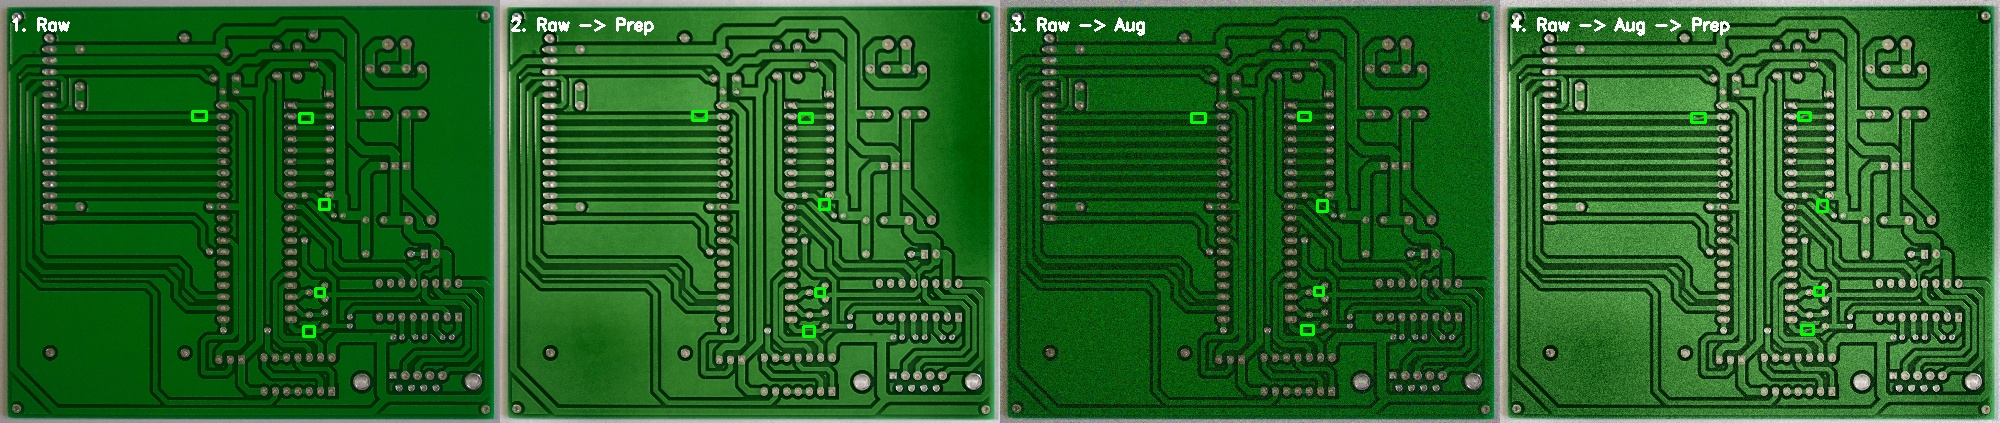

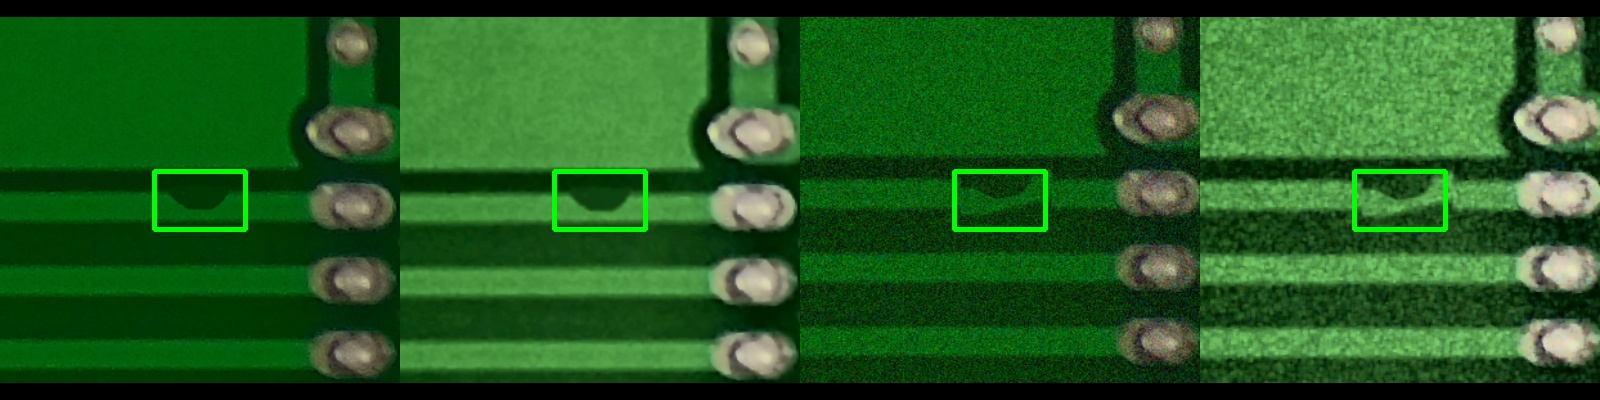

In [49]:
# ==============================================================================
# CELL 2: PARAMETER PREVIEW & PIPELINE VISUALIZATION (AUGMENT -> PREPROCESS)
# ==============================================================================

def preview_pipeline(
    image_dir, 
    annotation_dir, 
    sigma_range=(15, 25), 
    angle_range=(-15, 15), 
    jitter_range=(5, 10),
    preview_zoom_padding=120,
    seed=42
):
    """
    Visualizes the Industrial Sequence: 
    Raw -> Augmentation (Noise/Rotation) -> Preprocessing (Clean/Enhance)
    """
    if seed is not None:
        set_seed(seed)

    img_path_obj, ann_path_obj = Path(image_dir), Path(annotation_dir)
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp')
    image_paths = sorted([p for p in img_path_obj.rglob('*') if p.suffix.lower() in valid_exts])
    
    if not image_paths:
        log_message(f"⚠️ No images found in: {image_dir}")
        return
        
    target_sample_paths = [p for p in image_paths if p.parent.name.lower() in ['mouse_bite', 'missing_hole']]
    sample_path = random.choice(target_sample_paths) if target_sample_paths else random.choice(image_paths)
    xml_path = ann_path_obj / sample_path.relative_to(img_path_obj).parent / f"{sample_path.stem}.xml"
    
    img_bgr = cv2.imread(str(sample_path))
    if img_bgr is None: return
    h, w = img_bgr.shape[:2]

    # --- STEP 1: AUGMENTATION FIRST ---
    mid_sigma = sum(sigma_range) // 2
    mid_angle = sum(angle_range) / 2.0 or 12.0
    
    # Create the Augmented Raw Image (simulating a noisy capture)
    aug_raw = img_bgr.copy()
    class_name_lower = sample_path.parent.name.lower()
    if class_name_lower in ["missing_hole", "mouse_bite"]:
        aug_raw = rotate_bbox_only(aug_raw, xml_path, angle=mid_angle)
    aug_raw = add_gaussian_noise(aug_raw, sigma=mid_sigma)
    
    # --- STEP 2: PREPROCESS THE RESULTS ---
    # Col 2: Preprocess the original
    prep_original = preprocess_pcb_image(img_bgr)
    
    # Col 4: Preprocess the augmented/noisy version (This is what the model eventually sees)
    prep_aug = preprocess_pcb_image(aug_raw)

    # --- STEP 3: COORDINATE TRANSFORMATION (BBox Jitter) ---
    def get_preview_coords(xml_p, jitter=None):
        if not xml_p.exists(): return []
        root = ET.parse(xml_p).getroot()
        coords = []
        for obj in root.findall('object'):
            b = obj.find('bndbox')
            nx1, ny1, nx2, ny2 = transform_coords(
                float(b.find('xmin').text), float(b.find('ymin').text),
                float(b.find('xmax').text), float(b.find('ymax').text),
                h, w, jitter_range=jitter
            )
            coords.append((nx1, ny1, nx2, ny2))
        return coords

    coords_orig = get_preview_coords(xml_path, jitter=None)
    coords_jitter = get_preview_coords(xml_path, jitter=jitter_range)

    # --- STEP 4: GRID RENDERING ---
    dim_g, scale_g = calculate_resized_dimensions(h, w, max_dim=500)
    
    def draw_global(base_img, coord_list):
        canvas = cv2.resize(base_img, dim_g)
        for (x1, y1, x2, y2) in coord_list:
            cv2.rectangle(canvas, (int(x1*scale_g), int(y1*scale_g)), (int(x2*scale_g), int(y2*scale_g)), (0, 255, 0), 2)
        return canvas

    p1 = draw_global(img_bgr, coords_orig)      # Raw
    p2 = draw_global(prep_original, coords_orig) # Raw -> Prep
    p3 = draw_global(aug_raw, coords_jitter)    # Raw -> Aug
    p4 = draw_global(prep_aug, coords_jitter)   # Raw -> Aug -> Prep

    # --- STEP 5: ZOOM RENDERING ---
    if coords_orig:
        ox1, oy1, ox2, oy2 = coords_orig[0]
        jx1, jy1, jx2, jy2 = coords_jitter[0]
        
        def get_zoom_patch(src, x1, y1, x2, y2):
            cx1, cy1 = max(0, x1-preview_zoom_padding), max(0, y1-preview_zoom_padding)
            cx2, cy2 = min(w, x2+preview_zoom_padding), min(h, y2+preview_zoom_padding)
            crop = src[int(cy1):int(cy2), int(cx1):int(cx2)]
            
            # Standardization: Letterboxing to 400x400
            h_c, w_c = crop.shape[:2]
            scale = min(400/w_c, 400/h_c)
            nw, nh = int(w_c * scale), int(h_c * scale)
            resized = cv2.resize(crop, (nw, nh))
            canvas = np.zeros((400, 400, 3), dtype=np.uint8)
            dx, dy = (400-nw)//2, (400-nh)//2
            canvas[dy:dy+nh, dx:dx+nw] = resized
            
            rx1 = (x1 - cx1) * scale + dx
            ry1 = (y1 - cy1) * scale + dy
            rx2 = (x2 - cx1) * scale + dx
            ry2 = (y2 - cy1) * scale + dy
            cv2.rectangle(canvas, (int(rx1), int(ry1)), (int(rx2), int(ry2)), (0, 255, 0), 3)
            return canvas

        z1 = get_zoom_patch(img_bgr, ox1, oy1, ox2, oy2)
        z2 = get_zoom_patch(prep_original, ox1, oy1, ox2, oy2)
        z3 = get_zoom_patch(aug_raw, jx1, jy1, jx2, jy2)
        z4 = get_zoom_patch(prep_aug, jx1, jy1, jx2, jy2)
    else:
        z1 = z2 = z3 = z4 = np.zeros((400, 400, 3), dtype=np.uint8)

    grid_g = np.hstack([p1, p2, p3, p4])
    grid_z = np.hstack([z1, z2, z3, z4])
    
    titles = ["1. Raw", "2. Raw -> Prep", "3. Raw -> Aug", "4. Raw -> Aug -> Prep"]
    for i, txt in enumerate(titles):
        cv2.putText(grid_g, txt, (10 + i*dim_g[0], 30), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 2)

    log_message(f"ℹ️ Previewing Logic: Augmentation applied before Preprocessing (Seed: {seed})")
    log_message(f"   -> Preprocessing: Bilateral Filter & CLAHE only.")
    
    display(Image(data=cv2.imencode('.jpg', grid_g)[1].tobytes()))
    display(Image(data=cv2.imencode('.jpg', grid_z)[1].tobytes()))

# --- EXECUTION ---
preview_pipeline(
    image_dir='dataset/PCB_DATASET/images',
    annotation_dir='dataset/PCB_DATASET/Annotations',
    sigma_range=(15, 25),
    angle_range=(-15, 15),
    jitter_range=(5, 10),
    seed=42
)

## 1. Perform Augmentation

In [50]:
# ==============================================================================
# PERFORM BATCH AUGMENTATION & PREPROCESSING
# ==============================================================================

def reset_augmented_data(*folder_paths):
    """
    Recursively deletes specified folders to reset workspace with logging.
    Ensures a clean slate before generating new augmented data.
    """
    deleted = False
    for folder in folder_paths:
        path_obj = Path(folder)
        if path_obj.exists():
            shutil.rmtree(path_obj)
            log_message(f"🗑️ Removed directory tree: {path_obj}")
            deleted = True
            
        path_obj.mkdir(parents=True, exist_ok=True)
        
    if not deleted:
        log_message("⚠️ Specified directories did not exist. Created new empty folders.")

# 1. Lock global seeds before resetting and generating
set_seed(42)

# 2. Reset and clear old folders to ensure a clean slate
# Uses the helper function from your previous workspace
reset_augmented_data(
    'dataset/PCB_DATASET/augmented_images',
    'dataset/PCB_DATASET/augmented_annotations'
)

# 3. Run batch generation 
# Note: Exposure (Gamma) and Brightness (Beta) are removed as requested.
# The focus is now on Noise, ROI Rotation, and BBox Jitter followed by Prep.
augment_dataset(
    image_dir='dataset/PCB_DATASET/images',
    annotation_dir='dataset/PCB_DATASET/Annotations',
    output_img_dir='dataset/PCB_DATASET/augmented_images',
    output_xml_dir='dataset/PCB_DATASET/augmented_annotations',
    sample_ratio=0.8,               # Process 80% of the dataset
    sigma_range=(15, 25),           # Industrial sensor noise
    angle_range=(-15, 15),          # Local defect rotation
    jitter_range=(5, 10),           # BBox coordinate offset (Ref: Huang & Wei)
    seed=42                         # Guarantees reproducible results
)

🗑️ Removed directory tree: dataset\PCB_DATASET\augmented_images
🗑️ Removed directory tree: dataset\PCB_DATASET\augmented_annotations

🚀 DATA AUGMENTATION & PREPROCESSING STARTED
   -> Sequence: Augment -> Preprocess (Bilateral + CLAHE)
   -> Target: 556 images (80.0%)


Processing:   0%|          | 0/556 [00:00<?, ?it/s]

✅ SUCCESSFULLY GENERATED 556 PREPROCESSED SAMPLES.


## 2. Generate Unified Dataset with structural board id segregation 

In [59]:
# ==============================================================================
# CELL 4: GENERATE UNIFIED DATASET WITH STRUCTURAL BOARD ID SEGREGATION
# ==============================================================================
# --- 1. Global Parameters ---
DATASET_PATH = "dataset/PCB_DATASET"
OUTPUT_DIR = "dataset_processed"

# Strict non-overlapping partitioning by Board ID
TRAIN_BOARDS = ["01", "04", "05", "06", "07", "08"]  
VAL_BOARDS   = ["09", "10"]                        
TEST_BOARDS  = ["11", "12"]                        

CLASS_NAMES = ["Missing_hole", "Mouse_bite", "Open_circuit", "Short", "Spur", "Spurious_copper"]

# Standard & Augmented data sources
DATA_SOURCES = [
    {"name": "original", "ann_dir": "Annotations", "img_dir": "images"},
    {"name": "augmented", "ann_dir": "augmented_annotations", "img_dir": "augmented_images"}
]

def generate_unified_dataset():
    log_message("⏳ Starting unified standard preprocessing & tri-stage dataset generation...")
    log_message(f"   -> Train: Boards {TRAIN_BOARDS} (Original + Aug)")
    log_message(f"   -> Val:   Boards {VAL_BOARDS} (Original Only)")
    log_message(f"   -> Test:  Boards {TEST_BOARDS} (Original Only)")
    print("-" * 65)

    # Initialize directory splits
    if os.path.exists(OUTPUT_DIR):
        shutil.rmtree(OUTPUT_DIR)

    for split in ["train", "val", "test"]:
        for cls in CLASS_NAMES:
            os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

    # Initialize tools from earlier cells
    calibrator = PCBCalibrator(pixels_per_mm=PIXELS_PER_MM)
    total_patches = 0
    
    for cls in CLASS_NAMES:
        split_counts = {"train": 0, "val": 0, "test": 0}
        
        for src in DATA_SOURCES:
            ann_path = os.path.join(DATASET_PATH, src["ann_dir"], cls)
            img_path = os.path.join(DATASET_PATH, src["img_dir"], cls)
            
            if not os.path.exists(ann_path): continue
                
            xml_files = sorted([f for f in os.listdir(ann_path) if f.endswith('.xml')])
            
            for xml_file in xml_files:
                # 1. Extract Board ID (e.g., "01" from "01_missing_hole_01.xml")
                board_id = xml_file.split('_')[0]
                
                # 2. Strict Leakage Prevention Logic
                target_split = None
                if board_id in TRAIN_BOARDS:
                    target_split = "train"
                elif board_id in VAL_BOARDS and src["name"] == "original":
                    target_split = "val"
                elif board_id in TEST_BOARDS and src["name"] == "original":
                    target_split = "test"
                
                if target_split is None: continue

                # 3. Path Management
                img_ext = ".jpg" # Default extension
                target_img_path = os.path.join(img_path, xml_file.replace('.xml', img_ext))
                if not os.path.exists(target_img_path): continue
                
                # 4. Image Loading & Calibration (Ref: Huang & Wei)
                raw_target = cv2.imread(target_img_path)
                if raw_target is None: continue
                
                # [Optional Alignment] 
                # Find template to align (e.g., dataset/PCB_DATASET/images/01.jpg)
                template_path = os.path.join(DATASET_PATH, "images", f"{board_id}.jpg")
                if os.path.exists(template_path):
                    ref_img = cv2.imread(template_path)
                    # Align the target image to the standard template before cropping
                    raw_target = calibrator.rectify_and_align(raw_target, ref_img)
                
                # 5. Unified Preprocessing (Bilateral + CLAHE)
                # Calling the shared function from Cell 1
                prep_target = preprocess_pcb_image(raw_target)
                
                # 6. Extract Standardized Patches (With Padding, NO stretching)
                xml_full_path = os.path.join(ann_path, xml_file)
                patches = extract_ground_truth_patches(prep_target, xml_full_path, target_size=TARGET_SIZE)
                
                # 7. Save Patches to Disk
                for p_idx, patch_data in enumerate(patches):
                    patch_img = patch_data["patch"]
                    save_name = f"{xml_file.replace('.xml', '')}_p{p_idx}.jpg"
                    save_path = os.path.join(OUTPUT_DIR, target_split, cls, save_name)
                    
                    cv2.imwrite(save_path, patch_img)
                    total_patches += 1
                    split_counts[target_split] += 1
                    
        log_message(f"✅ Class '{cls:<16}' -> Train:{split_counts['train']:<4} | Val:{split_counts['val']:<3} | Test:{split_counts['test']:<3}")
        
    print("-" * 65)
    log_message(f"🎉 Success! Generated {total_patches} unified patches in '{OUTPUT_DIR}'.")

generate_unified_dataset()

⏳ Starting unified standard preprocessing & tri-stage dataset generation...
   -> Train: Boards ['01', '04', '05', '06', '07', '08'] (Original + Aug)
   -> Val:   Boards ['09', '10'] (Original Only)
   -> Test:  Boards ['11', '12'] (Original Only)
-----------------------------------------------------------------
✅ Class 'Missing_hole    ' -> Train:568  | Val:78  | Test:102
✅ Class 'Mouse_bite      ' -> Train:560  | Val:76  | Test:100
✅ Class 'Open_circuit    ' -> Train:535  | Val:81  | Test:101
✅ Class 'Short           ' -> Train:551  | Val:75  | Test:101
✅ Class 'Spur            ' -> Train:566  | Val:75  | Test:101
✅ Class 'Spurious_copper ' -> Train:575  | Val:82  | Test:101
-----------------------------------------------------------------
🎉 Success! Generated 4428 unified patches in 'dataset_processed'.


## Load Preprocessed Dataset

📊 Dataset Statistics:
-----------------------------------------------------------------
ID 0 | Missing_hole     | Count: 568   | 16.9%
ID 1 | Mouse_bite       | Count: 560   | 16.7%
ID 2 | Open_circuit     | Count: 535   | 15.9%
ID 3 | Short            | Count: 551   | 16.4%
ID 4 | Spur             | Count: 566   | 16.9%
ID 5 | Spurious_copper  | Count: 575   | 17.1%
✅ DataLoaders Ready. Device: cuda


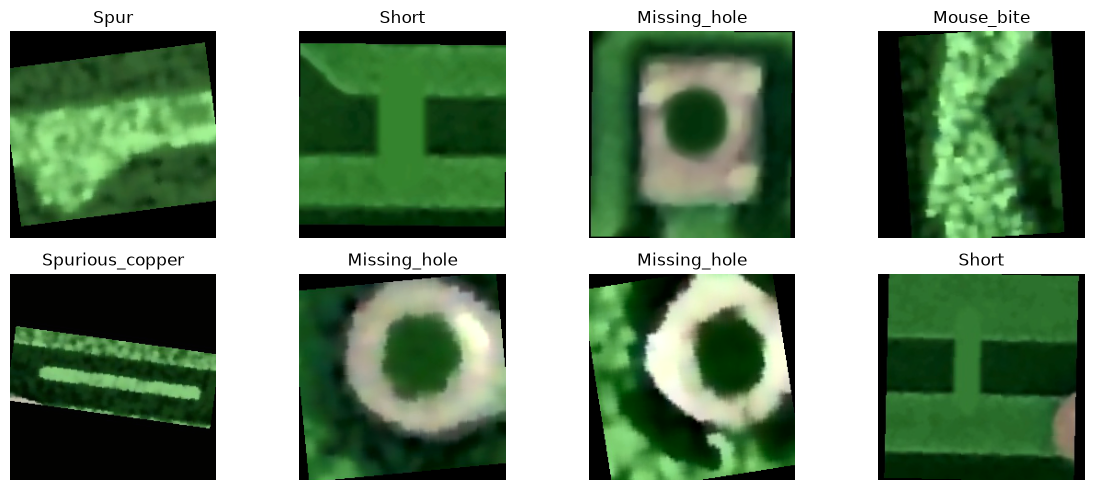

In [60]:
# ==============================================================================
# PHASE 2: DATALOADERS CREATION (OPTIMIZED FOR PCB DEFECTS)
# ==============================================================================
import os
import torch
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Define Transforms ---
# We keep online augmentation light because Offline augmentation is already done.
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=10), # Reduced slightly to avoid excessive warping
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Micro-adjustments
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 2. Load Datasets ---
PROCESSED_DIR = "dataset_processed"
train_dataset = datasets.ImageFolder(root=os.path.join(PROCESSED_DIR, "train"), transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=os.path.join(PROCESSED_DIR, "val"),   transform=eval_transforms)
test_dataset  = datasets.ImageFolder(root=os.path.join(PROCESSED_DIR, "test"),  transform=eval_transforms)

# --- 3. Compute Sampling Weights for Better Class Balance ---
targets = train_dataset.targets
class_count = np.unique(targets, return_counts=True)[1]
# Weight for each SAMPLE in the training set
weight = 1. / class_count
samples_weight = torch.from_numpy(weight[targets])
sampler = WeightedRandomSampler(samples_weight.type('torch.DoubleTensor'), len(samples_weight))

# --- 4. Instantiate DataLoaders ---
BATCH_SIZE = 32
# Use sampler for train_loader instead of shuffle=True
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# --- 5. Verify & Compute Loss Weights (Backup Strategy) ---
print("📊 Dataset Statistics:")
print("-" * 65)
total = len(train_dataset)
class_weights = []
for idx, class_name in enumerate(train_dataset.classes):
    count = (np.array(targets) == idx).sum()
    print(f"ID {idx} | {class_name:<16} | Count: {count:<5} | {100*count/total:.1f}%")
    class_weights.append(total / (len(train_dataset.classes) * count))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

# --- 6. VISUALIZATION CHECK ---
def show_batch(dl):
    img_batch, label_batch = next(iter(dl))
    plt.figure(figsize=(12, 5))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        # Un-normalize for visualization
        img = img_batch[i].numpy().transpose((1, 2, 0))
        img = np.clip(img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
        plt.imshow(img)
        plt.title(train_dataset.classes[label_batch[i]])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

log_message(f"✅ DataLoaders Ready. Device: {device}")
show_batch(train_loader)

In [61]:
## Detection & Patch Extraction for the 4 Algorithm

In [74]:
# ==============================================================================
# PHASE 3 & 6: BASELINE MODELS, HPO, AND TUNED MODEL INITIALIZATION
# ==============================================================================

import datetime
import random

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

from sklearn.metrics import average_precision_score

try:
    import optuna
except ImportError:
    raise ImportError("Please install Optuna first: pip install optuna")


# ------------------------------------------------------------------------------
# Logging
# ------------------------------------------------------------------------------

def log_message(message):
    """Print a message and append it to the persistent experiment log."""
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    formatted_message = f"[{timestamp}] {message}"

    print(message)

    with open(LOG_FILE_PATH, "a", encoding="utf-8") as log_file:
        log_file.write(formatted_message + "\n")


with open(LOG_FILE_PATH, "a", encoding="utf-8") as log_file:
    log_file.write("\n" + "=" * 80 + "\n")
    log_file.write(
        f"BASELINE AND HPO SESSION STARTED AT {datetime.datetime.now()}\n"
    )
    log_file.write("=" * 80 + "\n")


# ------------------------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------------------------

def set_seed(seed=42):
    """Set random seeds for reproducible experiments."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)


# ------------------------------------------------------------------------------
# Shared configuration
# ------------------------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 6

GLOBAL_SHARED_PARAMS = {
    "lr": 5e-5,
    "optimizer": optim.AdamW,
    "epochs_per_trial": 3,
    "label_smoothing": 0.1,
    "batch_size": BATCH_SIZE,
}


# ------------------------------------------------------------------------------
# Lightweight Vision Transformer
# ------------------------------------------------------------------------------

class LightweightViT(nn.Module):
    """A lightweight Vision Transformer for PCB defect classification."""

    def __init__(
        self,
        num_classes=NUM_CLASSES,
        img_size=224,
        patch_size=16,
        embed_dim=192,
        depth=6,
        num_heads=3,
        mlp_ratio=2.0,
    ):
        super().__init__()

        num_patches = (img_size // patch_size) ** 2

        self.patch_embed = nn.Conv2d(
            in_channels=3,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches + 1, embed_dim)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            activation="gelu",
            batch_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth,
        )

        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x).flatten(2).transpose(1, 2)

        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embed
        x = self.transformer(x)

        return self.head(x[:, 0])


# ------------------------------------------------------------------------------
# CNN model factories
# ------------------------------------------------------------------------------

def get_cs_resnet(num_classes=NUM_CLASSES, dropout_p=0.0):
    """Create a ResNet-18 with configurable classifier dropout."""
    model = models.resnet18(weights=None)

    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(in_features, num_classes),
    )

    return model


def get_mobilenet_v3(num_classes=NUM_CLASSES, dropout_p=0.2):
    """Create a MobileNetV3-Small with configurable classifier dropout."""
    model = models.mobilenet_v3_small(weights=None)

    model.classifier[2].p = dropout_p
    model.classifier[3] = nn.Linear(
        model.classifier[3].in_features,
        num_classes,
    )

    return model


def get_alexnet(num_classes=NUM_CLASSES, dropout_p=0.5):
    """Create an AlexNet with configurable classifier dropout."""
    model = models.alexnet(weights=None)

    model.classifier[2].p = dropout_p
    model.classifier[5].p = dropout_p
    model.classifier[6] = nn.Linear(
        model.classifier[6].in_features,
        num_classes,
    )

    return model


# ------------------------------------------------------------------------------
# Model builder
# ------------------------------------------------------------------------------

def build_model(model_name, params=None):
    """Build a model using default or HPO-selected model-specific parameters."""
    params = params or {}

    if "LPViT" in model_name:
        return LightweightViT(
            num_classes=NUM_CLASSES,
            num_heads=params.get("num_heads", 3),
            mlp_ratio=params.get("mlp_ratio", 2.0),
        )

    if "CS-ResNet" in model_name:
        return get_cs_resnet(
            num_classes=NUM_CLASSES,
            dropout_p=params.get("dropout_p", 0.0),
        )

    if "MobileNetV3" in model_name:
        return get_mobilenet_v3(
            num_classes=NUM_CLASSES,
            dropout_p=params.get("dropout_p", 0.2),
        )

    if "AlexNet" in model_name:
        return get_alexnet(
            num_classes=NUM_CLASSES,
            dropout_p=params.get("dropout_p", 0.5),
        )

    raise ValueError(f"Unsupported model name: {model_name}")


# ------------------------------------------------------------------------------
# Hyperparameter optimization
# ------------------------------------------------------------------------------

def tuning_objective(trial, model_name):
    """Train one trial and return its best validation macro mAP."""
    set_seed(42)

    if "LPViT" in model_name:
        params = {
            "num_heads": trial.suggest_categorical(
                "num_heads",
                [3, 4, 6],
            ),
            "mlp_ratio": trial.suggest_categorical(
                "mlp_ratio",
                [2.0, 4.0],
            ),
        }

    elif "CS-ResNet" in model_name:
        params = {
            "dropout_p": trial.suggest_float(
                "dropout_p",
                0.0,
                0.5,
            ),
        }

    elif "MobileNetV3" in model_name:
        params = {
            "dropout_p": trial.suggest_float(
                "dropout_p",
                0.0,
                0.5,
            ),
        }

    elif "AlexNet" in model_name:
        params = {
            "dropout_p": trial.suggest_float(
                "dropout_p",
                0.2,
                0.5,
            ),
        }

    else:
        raise ValueError(f"Unsupported HPO model: {model_name}")

    model = build_model(
        model_name=model_name,
        params=params,
    ).to(device)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor,
        label_smoothing=GLOBAL_SHARED_PARAMS["label_smoothing"],
    )

    optimizer = GLOBAL_SHARED_PARAMS["optimizer"](
        model.parameters(),
        lr=GLOBAL_SHARED_PARAMS["lr"],
    )

    best_map = 0.0

    for _ in range(GLOBAL_SHARED_PARAMS["epochs_per_trial"]):
        model.train()

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

        model.eval()
        all_labels = []
        all_probabilities = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)

                outputs = model(images)
                probabilities = torch.softmax(outputs, dim=1)

                all_labels.extend(labels.numpy())
                all_probabilities.extend(probabilities.cpu().numpy())

        one_hot_labels = np.eye(NUM_CLASSES)[np.array(all_labels)]

        current_map = average_precision_score(
            one_hot_labels,
            np.array(all_probabilities),
            average="macro",
        )

        best_map = max(best_map, current_map)

    return best_map


def execute_master_tuning(n_trials=5):
    """Run an equal HPO budget for all four model families."""
    tuning_targets = [
        "LPViT (Custom ViT)",
        "CS-ResNet (ResNet18)",
        "MobileNetV3 (Small)",
        "AlexNet (Auto-VRS)",
    ]

    best_params_report = {}

    log_message("MASTER HYPERPARAMETER TUNING INITIALIZED")
    log_message(f"Shared learning rate: {GLOBAL_SHARED_PARAMS['lr']}")
    log_message(
        "Shared loss: CrossEntropy with "
        f"label smoothing {GLOBAL_SHARED_PARAMS['label_smoothing']}"
    )
    log_message("Selection metric: validation macro mAP")
    log_message("=" * 75)

    optuna.logging.set_verbosity(optuna.logging.WARNING)

    for model_name in tuning_targets:
        log_message(f"Tuning model: {model_name}")

        study = optuna.create_study(direction="maximize")

        study.optimize(
            lambda trial: tuning_objective(trial, model_name),
            n_trials=n_trials,
        )

        best_params_report[model_name] = study.best_params

        log_message(f"Best validation mAP: {study.best_value:.4f}")
        log_message(f"Best parameters: {study.best_params}")
        log_message("-" * 75)

    return best_params_report


# ------------------------------------------------------------------------------
# Baseline model initialization
# ------------------------------------------------------------------------------

def initialize_baseline_models():
    """Create four default baseline models without HPO-selected parameters."""
    global lpvit_sim
    global cs_resnet
    global mobilenet
    global alexnet

    set_seed(42)

    lpvit_sim = LightweightViT(
        num_classes=NUM_CLASSES,
    ).to(device)

    cs_resnet = get_cs_resnet(
        num_classes=NUM_CLASSES,
        dropout_p=0.0,
    ).to(device)

    mobilenet = get_mobilenet_v3(
        num_classes=NUM_CLASSES,
        dropout_p=0.2,
    ).to(device)

    alexnet = get_alexnet(
        num_classes=NUM_CLASSES,
        dropout_p=0.5,
    ).to(device)

    log_message("Default baseline models initialized.")


# ------------------------------------------------------------------------------
# HPO-tuned model initialization
# ------------------------------------------------------------------------------

def initialize_tuned_models(best_params):
    """Create four new models using the selected HPO parameters."""
    global lpvit_tuned
    global cs_resnet_tuned
    global mobilenet_tuned
    global alexnet_tuned

    required_model_names = [
        "LPViT (Custom ViT)",
        "CS-ResNet (ResNet18)",
        "MobileNetV3 (Small)",
        "AlexNet (Auto-VRS)",
    ]

    missing_names = [
        name
        for name in required_model_names
        if name not in best_params
    ]

    if missing_names:
        raise ValueError(
            "Missing HPO results for: " + ", ".join(missing_names)
        )

    set_seed(42)

    lpvit_tuned = build_model(
        "LPViT",
        best_params["LPViT (Custom ViT)"],
    ).to(device)

    cs_resnet_tuned = build_model(
        "CS-ResNet",
        best_params["CS-ResNet (ResNet18)"],
    ).to(device)

    mobilenet_tuned = build_model(
        "MobileNetV3",
        best_params["MobileNetV3 (Small)"],
    ).to(device)

    alexnet_tuned = build_model(
        "AlexNet",
        best_params["AlexNet (Auto-VRS)"],
    ).to(device)

    log_message("HPO-tuned models initialized from scratch.")


def count_parameters(model):
    """Count all trainable parameters in a model."""
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


# ------------------------------------------------------------------------------
# Create baseline models
# ------------------------------------------------------------------------------

initialize_baseline_models()

log_message("Default baseline parameter counts:")
log_message("-" * 65)
log_message(f"LPViT: {count_parameters(lpvit_sim):,}")
log_message(f"CS-ResNet: {count_parameters(cs_resnet):,}")
log_message(f"MobileNetV3: {count_parameters(mobilenet):,}")
log_message(f"AlexNet: {count_parameters(alexnet):,}")
log_message("-" * 65)

Default baseline models initialized.
Default baseline parameter counts:
-----------------------------------------------------------------
LPViT: 1,968,966
CS-ResNet: 11,179,590
MobileNetV3: 1,524,006
AlexNet: 57,028,422
-----------------------------------------------------------------


In [76]:
# ==============================================================================
# PHASE 4: UNIFIED TRAINING AND VALIDATION RUNNER
# ==============================================================================

import copy
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import average_precision_score


# ------------------------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------------------------

class EarlyStopping:
    """Stop training when validation mAP no longer improves."""

    def __init__(self, patience=5, min_delta=1e-4, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose

        self.best_score = -np.inf
        self.counter = 0
        self.early_stop = False

    def __call__(self, score):
        """Return True when a new best validation mAP is found."""
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter = 0
            return True

        self.counter += 1

        if self.verbose:
            log_message(
                "Validation mAP did not improve. "
                f"Counter: {self.counter}/{self.patience}"
            )

        if self.counter >= self.patience:
            self.early_stop = True

        return False


# ------------------------------------------------------------------------------
# Training and validation functions
# ------------------------------------------------------------------------------

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Train one model for one complete epoch."""
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += predictions.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def validate_and_profile_latency(model, dataloader, criterion, device):
    """Compute validation loss, accuracy, macro mAP, and inference latency."""
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    latencies_ms = []
    all_probabilities = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if device.type == "cuda":
                torch.cuda.synchronize()

            start_time = time.perf_counter()

            outputs = model(images)

            if device.type == "cuda":
                torch.cuda.synchronize()

            end_time = time.perf_counter()

            batch_latency_ms = (end_time - start_time) * 1000.0
            latencies_ms.append(batch_latency_ms / images.size(0))

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += predictions.eq(labels).sum().item()
            total += labels.size(0)

            probabilities = torch.softmax(outputs, dim=1)

            all_probabilities.extend(probabilities.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    num_classes = len(dataloader.dataset.classes)

    one_hot_labels = np.eye(num_classes)[np.array(all_labels)]

    macro_map = average_precision_score(
        one_hot_labels,
        np.array(all_probabilities),
        average="macro",
    )

    average_latency_ms = float(np.mean(latencies_ms))

    return (
        running_loss / total,
        correct / total,
        average_latency_ms,
        macro_map,
    )


# ------------------------------------------------------------------------------
# Model group selection
# ------------------------------------------------------------------------------

def get_model_group(mode):
    """Return the correct four-model group for the selected experiment mode."""
    if mode == "baseline":
        return {
            "LPViT (Baseline)": lpvit_sim,
            "CS-ResNet (Baseline)": cs_resnet,
            "MobileNetV3 (Baseline)": mobilenet,
            "AlexNet (Baseline)": alexnet,
        }

    if mode == "tuned":
        required_variables = [
            "lpvit_tuned",
            "cs_resnet_tuned",
            "mobilenet_tuned",
            "alexnet_tuned",
        ]

        missing_variables = [
            variable
            for variable in required_variables
            if variable not in globals()
        ]

        if missing_variables:
            raise RuntimeError(
                "Tuned models have not been initialized. "
                "Run execute_master_tuning(...) and "
                "initialize_tuned_models(BEST_PARAMS) first. "
                f"Missing: {', '.join(missing_variables)}"
            )

        return {
            "LPViT (HPO-Tuned)": lpvit_tuned,
            "CS-ResNet (HPO-Tuned)": cs_resnet_tuned,
            "MobileNetV3 (HPO-Tuned)": mobilenet_tuned,
            "AlexNet (HPO-Tuned)": alexnet_tuned,
        }

    raise ValueError("Mode must be either 'baseline' or 'tuned'.")


# ------------------------------------------------------------------------------
# Unified experiment runner
# ------------------------------------------------------------------------------

def run_experiment(epochs=30, patience=7, lr=1e-4, mode="baseline"):
    """
    Train and validate one group of four models.

    The test set is intentionally not used here.
    It must only be used later in the final benchmark phase.
    """
    model_group = get_model_group(mode)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor,
        label_smoothing=GLOBAL_SHARED_PARAMS["label_smoothing"],
    )

    log_message("=" * 75)
    log_message(f"EXPERIMENT MODE: {mode.upper()}")
    log_message(f"Learning rate: {lr}")
    log_message(f"Maximum epochs: {epochs}")
    log_message(f"Early stopping patience: {patience}")
    log_message("=" * 75)

    comparison_results = []

    for model_name, model in model_group.items():
        model = model.to(device)

        optimizer = optim.AdamW(
            model.parameters(),
            lr=lr,
        )

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=epochs,
        )

        early_stopping = EarlyStopping(
            patience=patience,
            min_delta=1e-4,
            verbose=True,
        )

        best_model_weights = copy.deepcopy(model.state_dict())

        best_val_accuracy = 0.0
        best_val_map = -np.inf
        best_latency_ms = 0.0
        best_epoch = 0

        log_message("")
        log_message("=" * 75)
        log_message(f"Training started: {model_name}")
        log_message("=" * 75)

        for epoch in range(1, epochs + 1):
            train_loss, train_accuracy = train_one_epoch(
                model=model,
                dataloader=train_loader,
                criterion=criterion,
                optimizer=optimizer,
                device=device,
            )

            (
                val_loss,
                val_accuracy,
                latency_ms,
                val_map,
            ) = validate_and_profile_latency(
                model=model,
                dataloader=val_loader,
                criterion=criterion,
                device=device,
            )

            scheduler.step()

            improved = early_stopping(val_map)

            if improved:
                best_model_weights = copy.deepcopy(model.state_dict())
                best_val_accuracy = val_accuracy
                best_val_map = val_map
                best_latency_ms = latency_ms
                best_epoch = epoch

            log_message(
                f"Epoch {epoch:02d}/{epochs:02d} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_accuracy * 100:.2f}% | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Acc: {val_accuracy * 100:.2f}% | "
                f"Val mAP: {val_map:.4f}"
            )

            if early_stopping.early_stop:
                log_message(
                    f"Early stopping triggered at epoch {epoch}. "
                    "Restoring the best validation-mAP weights."
                )
                break

        model.load_state_dict(best_model_weights)

        comparison_results.append(
            {
                "Model": model_name,
                "Best Epoch": best_epoch,
                "Best Val Acc (%)": round(best_val_accuracy * 100, 2),
                "Best Val mAP": round(best_val_map, 4),
                "Latency (ms/image)": round(best_latency_ms, 4),
            }
        )

    summary_df = pd.DataFrame(comparison_results)

    log_message("")
    log_message("=" * 75)
    log_message(f"{mode.upper()} VALIDATION SUMMARY")
    log_message("=" * 75)
    log_message(summary_df.to_string(index=False))

    with open(LOG_FILE_PATH, "a", encoding="utf-8") as log_file:
        log_file.write("\n")
        log_file.write(f"{mode.upper()} VALIDATION SUMMARY\n")
        log_file.write(summary_df.to_string(index=False))
        log_file.write("\n\n")

    display(summary_df)

    return summary_df


print("Phase 4 unified training runner is ready.")

Phase 4 unified training runner is ready.


In [68]:
## Pipeline Execution & Comparative Visualization

In [80]:
# ==============================================================================
# PHASE 5: FINAL TEST-SET BENCHMARK FOR BASELINE AND HPO-TUNED MODELS
# ==============================================================================

import os
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)

try:
    from thop import profile
except ImportError:
    profile = None
    print("THOP is unavailable. GFLOPs and parameter profiling will be skipped.")


# ------------------------------------------------------------------------------
# Utility functions
# ------------------------------------------------------------------------------

def safe_filename(name):
    """Convert a model name into a Windows-safe filename."""
    return re.sub(r'[<>:"/\\|?*]', "_", name).replace(" ", "_")


def profile_model(model, device):
    """Return model GFLOPs and trainable parameter count."""
    parameter_count = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    parameters_m = parameter_count / 1e6

    if profile is None:
        return np.nan, parameters_m

    dummy_input = torch.randn(1, 3, 224, 224, device=device)

    try:
        flops, _ = profile(
            model,
            inputs=(dummy_input,),
            verbose=False,
        )

        return flops / 1e9, parameters_m

    except Exception as error:
        log_message(
            f"GFLOPs profiling failed for {model.__class__.__name__}: {error}"
        )

        return np.nan, parameters_m


def save_confusion_matrix(
    confusion_matrix_values,
    class_names,
    model_name,
    output_directory,
):
    """Save a labeled confusion matrix image for one evaluated model."""
    figure, axis = plt.subplots(figsize=(7, 6))

    sns.heatmap(
        confusion_matrix_values,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True,
        ax=axis,
    )

    axis.set_title(f"Confusion Matrix: {model_name}", fontweight="bold", pad=16)
    axis.set_xlabel("Predicted Label", fontweight="bold")
    axis.set_ylabel("Actual Label", fontweight="bold")

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    output_path = os.path.join(
        output_directory,
        f"{safe_filename(model_name)}_confusion_matrix.png",
    )

    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(figure)

    return output_path


# ------------------------------------------------------------------------------
# Final benchmark function
# ------------------------------------------------------------------------------

def benchmark_on_test_set(evaluation_targets, test_loader):
    """
    Evaluate all supplied models once on the untouched test set.

    The models must already contain the best validation-mAP weights selected
    during Phase 4 training.
    """
    output_directory = "Benchmark_Results"
    os.makedirs(output_directory, exist_ok=True)

    class_names = test_loader.dataset.classes
    num_classes = len(class_names)

    results_list = []

    log_message("=" * 80)
    log_message(
        f"FINAL TEST BENCHMARK STARTED FOR {len(evaluation_targets)} MODELS"
    )
    log_message("=" * 80)

    for target in evaluation_targets:
        model = target["model"]
        target_device = target["device"]
        model_name = target["name"]

        log_message(f"Evaluating: {model_name} on {target_device}")

        model = model.to(target_device)
        model.eval()

        gflops, parameters_m = profile_model(
            model=model,
            device=target_device,
        )

        warmup_input = torch.randn(
            1,
            3,
            224,
            224,
            device=target_device,
        )

        with torch.inference_mode():
            for _ in range(10):
                _ = model(warmup_input)

        if target_device.type == "cuda":
            torch.cuda.synchronize()

        all_predictions = []
        all_targets = []
        all_probabilities = []
        latencies_ms = []

        with torch.inference_mode():
            for images, labels in test_loader:
                images = images.to(target_device, non_blocking=True)
                labels = labels.to(target_device, non_blocking=True)

                if target_device.type == "cuda":
                    torch.cuda.synchronize()

                start_time = time.perf_counter()

                outputs = model(images)

                if target_device.type == "cuda":
                    torch.cuda.synchronize()

                end_time = time.perf_counter()

                latency_per_image_ms = (
                    (end_time - start_time) * 1000.0 / images.size(0)
                )

                latencies_ms.append(latency_per_image_ms)

                probabilities = torch.softmax(outputs, dim=1)
                predictions = outputs.argmax(dim=1)

                all_probabilities.extend(probabilities.cpu().numpy())
                all_predictions.extend(predictions.cpu().numpy())
                all_targets.extend(labels.cpu().numpy())

        all_targets = np.array(all_targets)
        all_predictions = np.array(all_predictions)
        all_probabilities = np.array(all_probabilities)

        one_hot_targets = np.eye(num_classes)[all_targets]

        accuracy = accuracy_score(all_targets, all_predictions)
        weighted_recall = recall_score(
            all_targets,
            all_predictions,
            average="weighted",
            zero_division=0,
        )
        macro_f1 = f1_score(
            all_targets,
            all_predictions,
            average="macro",
            zero_division=0,
        )
        weighted_f1 = f1_score(
            all_targets,
            all_predictions,
            average="weighted",
            zero_division=0,
        )
        macro_map = average_precision_score(
            one_hot_targets,
            all_probabilities,
            average="macro",
        )

        average_latency_ms = float(np.mean(latencies_ms))
        median_latency_ms = float(np.median(latencies_ms))

        matrix = confusion_matrix(
            all_targets,
            all_predictions,
            labels=np.arange(num_classes),
        )

        confusion_matrix_path = save_confusion_matrix(
            confusion_matrix_values=matrix,
            class_names=class_names,
            model_name=model_name,
            output_directory=output_directory,
        )

        report = classification_report(
            all_targets,
            all_predictions,
            labels=np.arange(num_classes),
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )

        report_df = pd.DataFrame(report).transpose()

        report_path = os.path.join(
            output_directory,
            f"{safe_filename(model_name)}_classification_report.csv",
        )

        report_df.to_csv(report_path)

        results_list.append(
            {
                "Model Name": model_name,
                "mAP (Academic)": round(macro_map, 4),
                "GFLOPs": round(gflops, 4) if not np.isnan(gflops) else np.nan,
                "Params (M)": round(parameters_m, 2),
                "Latency Mean (ms/image)": round(average_latency_ms, 4),
                "Latency Median (ms/image)": round(median_latency_ms, 4),
                "Accuracy (%)": round(accuracy * 100, 2),
                "Recall (Weighted, %)": round(weighted_recall * 100, 2),
                "F1-Score (Macro, %)": round(macro_f1 * 100, 2),
                "F1-Score (Weighted, %)": round(weighted_f1 * 100, 2),
                "Confusion Matrix": confusion_matrix_path,
                "Classification Report": report_path,
            }
        )

        log_message(
            f"Completed: {model_name} | "
            f"Test mAP: {macro_map:.4f} | "
            f"Accuracy: {accuracy * 100:.2f}%"
        )

    summary_df = pd.DataFrame(results_list)

    summary_df = summary_df.sort_values(
        by="mAP (Academic)",
        ascending=False,
    ).reset_index(drop=True)

    summary_path = os.path.join(
        output_directory,
        "final_benchmark_summary.csv",
    )

    summary_df.to_csv(summary_path, index=False)

    log_message("=" * 80)
    log_message("FINAL TEST BENCHMARK COMPLETED")
    log_message(f"Summary saved to: {summary_path}")
    log_message("=" * 80)

    display(summary_df)

    return summary_df

PHASE 1/4: TRAINING DEFAULT BASELINE MODELS
EXPERIMENT MODE: BASELINE
Learning rate: 0.0001
Maximum epochs: 30
Early stopping patience: 7

Training started: LPViT (Baseline)
Epoch 01/30 | Train Loss: 0.8747 | Train Acc: 76.01% | Val Loss: 0.9820 | Val Acc: 71.09% | Val mAP: 0.7899
Epoch 02/30 | Train Loss: 0.8691 | Train Acc: 76.30% | Val Loss: 0.9386 | Val Acc: 74.52% | Val mAP: 0.7999
Epoch 03/30 | Train Loss: 0.8149 | Train Acc: 78.75% | Val Loss: 0.9117 | Val Acc: 76.02% | Val mAP: 0.8248
Epoch 04/30 | Train Loss: 0.8020 | Train Acc: 80.33% | Val Loss: 1.0657 | Val Acc: 70.02% | Val mAP: 0.8271
Validation mAP did not improve. Counter: 1/7
Epoch 05/30 | Train Loss: 0.7934 | Train Acc: 81.07% | Val Loss: 0.9835 | Val Acc: 72.38% | Val mAP: 0.8008
Validation mAP did not improve. Counter: 2/7
Epoch 06/30 | Train Loss: 0.8108 | Train Acc: 79.52% | Val Loss: 0.9296 | Val Acc: 71.52% | Val mAP: 0.8109
Epoch 07/30 | Train Loss: 0.7504 | Train Acc: 82.98% | Val Loss: 1.0234 | Val Acc: 70.45

Epoch 09/30 | Train Loss: 0.6258 | Train Acc: 91.18% | Val Loss: 0.6565 | Val Acc: 89.08% | Val mAP: 0.9626
Epoch 10/30 | Train Loss: 0.6342 | Train Acc: 90.52% | Val Loss: 0.6317 | Val Acc: 91.01% | Val mAP: 0.9751
Validation mAP did not improve. Counter: 1/7
Epoch 11/30 | Train Loss: 0.6024 | Train Acc: 92.40% | Val Loss: 0.6433 | Val Acc: 90.79% | Val mAP: 0.9654
Epoch 12/30 | Train Loss: 0.5949 | Train Acc: 92.73% | Val Loss: 0.6072 | Val Acc: 92.72% | Val mAP: 0.9770
Validation mAP did not improve. Counter: 1/7
Epoch 13/30 | Train Loss: 0.5727 | Train Acc: 94.58% | Val Loss: 0.6111 | Val Acc: 93.15% | Val mAP: 0.9722
Validation mAP did not improve. Counter: 2/7
Epoch 14/30 | Train Loss: 0.5632 | Train Acc: 94.43% | Val Loss: 0.6233 | Val Acc: 90.79% | Val mAP: 0.9710
Validation mAP did not improve. Counter: 3/7
Epoch 15/30 | Train Loss: 0.5566 | Train Acc: 94.55% | Val Loss: 0.6036 | Val Acc: 91.86% | Val mAP: 0.9709
Epoch 16/30 | Train Loss: 0.5542 | Train Acc: 94.84% | Val Loss:

,Model,Best Epoch,Best Val Acc (%),Best Val mAP,Latency (ms/image)
0,LPViT (Baseline),28,83.51,0.8944,0.2908
1,CS-ResNet (Baseline),11,96.57,0.9971,0.4337
2,MobileNetV3 (Baseline),24,95.07,0.9848,0.2504
3,AlexNet (Baseline),14,98.72,0.9991,0.4453


PHASE 2/4: RUNNING MODEL-SPECIFIC HPO
MASTER HYPERPARAMETER TUNING INITIALIZED
Shared learning rate: 5e-05
Shared loss: CrossEntropy with label smoothing 0.1
Selection metric: validation macro mAP
Tuning model: LPViT (Custom ViT)


C:\ProgramData\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


...

C:\ProgramData\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


HPO-tuned models initialized from scratch.
PHASE 3/4: TRAINING HPO-TUNED MODELS
EXPERIMENT MODE: TUNED
Learning rate: 0.0001
Maximum epochs: 30
Early stopping patience: 7

Training started: LPViT (HPO-Tuned)
Epoch 01/30 | Train Loss: 1.4721 | Train Acc: 43.76% | Val Loss: 1.3725 | Val Acc: 54.18% | Val mAP: 0.5841
Epoch 02/30 | Train Loss: 1.2594 | Train Acc: 56.72% | Val Loss: 1.2765 | Val Acc: 55.03% | Val mAP: 0.6170
Epoch 03/30 | Train Loss: 1.1623 | Train Acc: 62.15% | Val Loss: 1.2452 | Val Acc: 62.31% | Val mAP: 0.6520
Epoch 04/30 | Train Loss: 1.1410 | Train Acc: 63.16% | Val Loss: 1.2122 | Val Acc: 62.53% | Val mAP: 0.6633
Epoch 05/30 | Train Loss: 1.0688 | Train Acc: 66.29% | Val Loss: 1.1853 | Val Acc: 59.10% | Val mAP: 0.6691
Epoch 06/30 | Train Loss: 1.0673 | Train Acc: 67.30% | Val Loss: 1.1673 | Val Acc: 65.10% | Val mAP: 0.6964
Validation mAP did not improve. Counter: 1/7
Epoch 07/30 | Train Loss: 1.0315 | Train Acc: 69.12% | Val Loss: 1.1862 | Val Acc: 63.17% | Val mAP

Epoch 01/30 | Train Loss: 1.4919 | Train Acc: 42.06% | Val Loss: 1.8031 | Val Acc: 17.34% | Val mAP: 0.2248
Epoch 02/30 | Train Loss: 1.0734 | Train Acc: 67.72% | Val Loss: 1.8398 | Val Acc: 16.27% | Val mAP: 0.2443
Epoch 03/30 | Train Loss: 0.9561 | Train Acc: 73.20% | Val Loss: 1.8850 | Val Acc: 16.27% | Val mAP: 0.3894
Epoch 04/30 | Train Loss: 0.8912 | Train Acc: 77.35% | Val Loss: 1.9996 | Val Acc: 16.27% | Val mAP: 0.4690
Epoch 05/30 | Train Loss: 0.8125 | Train Acc: 81.10% | Val Loss: 2.2025 | Val Acc: 16.27% | Val mAP: 0.4894
Epoch 06/30 | Train Loss: 0.7385 | Train Acc: 85.25% | Val Loss: 1.6110 | Val Acc: 37.47% | Val mAP: 0.7072
Epoch 07/30 | Train Loss: 0.6987 | Train Acc: 87.48% | Val Loss: 0.8453 | Val Acc: 79.44% | Val mAP: 0.8990
Epoch 08/30 | Train Loss: 0.6788 | Train Acc: 88.64% | Val Loss: 0.6992 | Val Acc: 88.65% | Val mAP: 0.9469
Epoch 09/30 | Train Loss: 0.6306 | Train Acc: 91.27% | Val Loss: 0.7149 | Val Acc: 88.22% | Val mAP: 0.9490
Epoch 10/30 | Train Loss: 0.

,Model,Best Epoch,Best Val Acc (%),Best Val mAP,Latency (ms/image)
0,LPViT (HPO-Tuned),27,76.87,0.8309,0.2909
1,CS-ResNet (HPO-Tuned),28,98.07,0.9983,0.4353
2,MobileNetV3 (HPO-Tuned),25,93.15,0.9830,0.2754
3,AlexNet (HPO-Tuned),14,97.64,0.9980,0.2292


PHASE 4/4: RUNNING FINAL TEST-SET BENCHMARK
FINAL TEST BENCHMARK STARTED FOR 8 MODELS
Evaluating: LPViT - Baseline on cuda


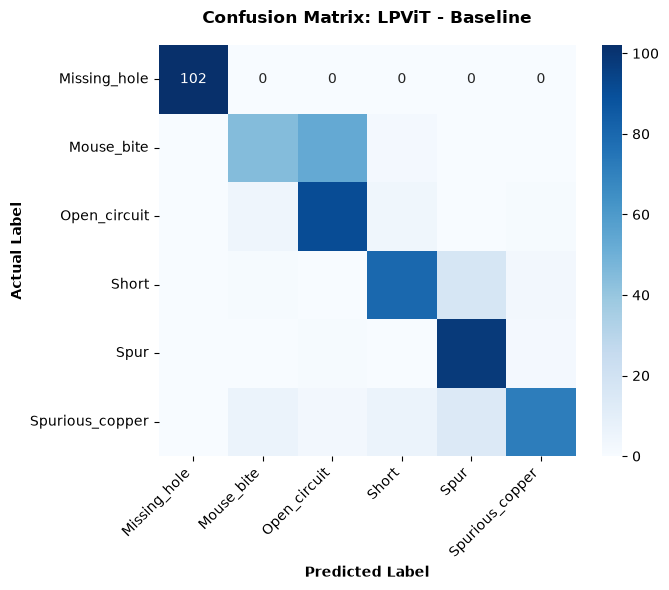

Completed: LPViT - Baseline | Test mAP: 0.8726 | Accuracy: 80.53%
Evaluating: CS-ResNet - Baseline on cuda


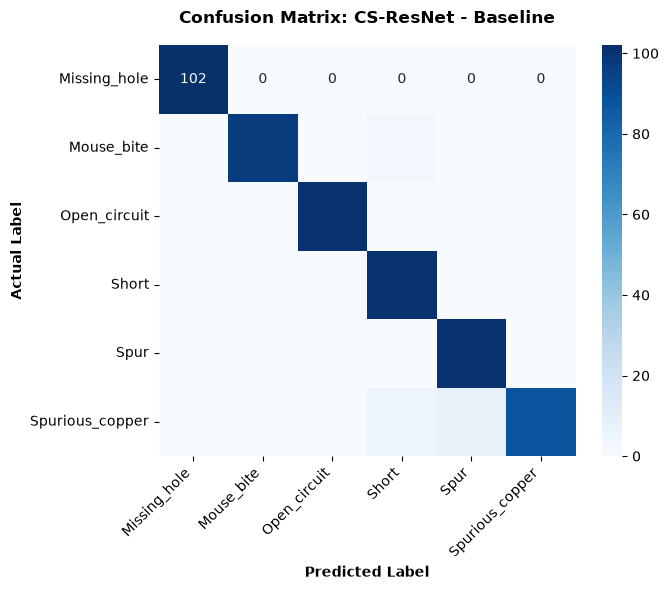

Completed: CS-ResNet - Baseline | Test mAP: 0.9962 | Accuracy: 97.36%
Evaluating: MobileNetV3 - Baseline on cuda


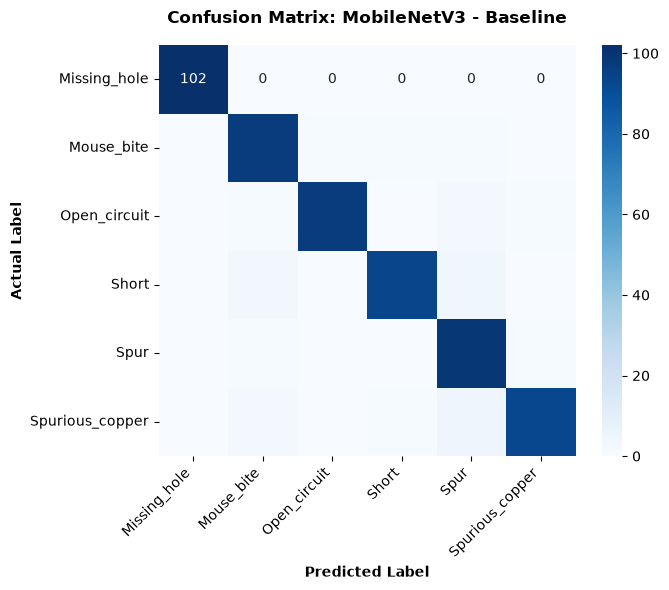

Completed: MobileNetV3 - Baseline | Test mAP: 0.9841 | Accuracy: 96.04%
Evaluating: AlexNet - Baseline on cuda


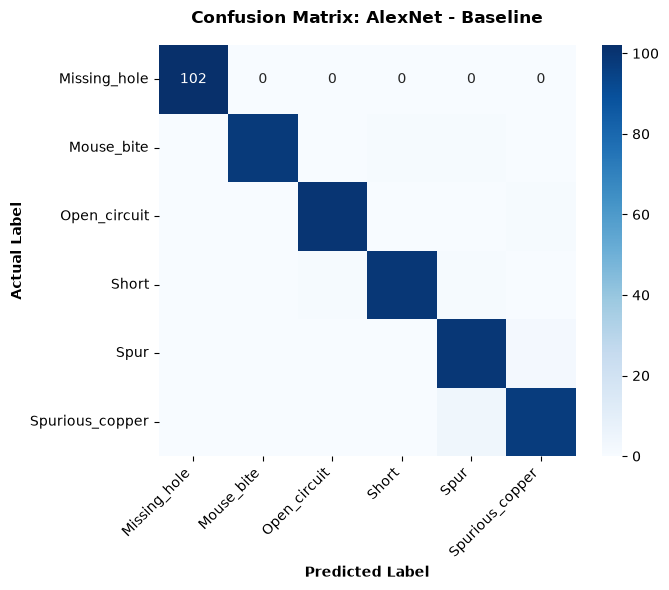

Completed: AlexNet - Baseline | Test mAP: 0.9981 | Accuracy: 98.18%
Evaluating: LPViT - HPO-Tuned on cuda


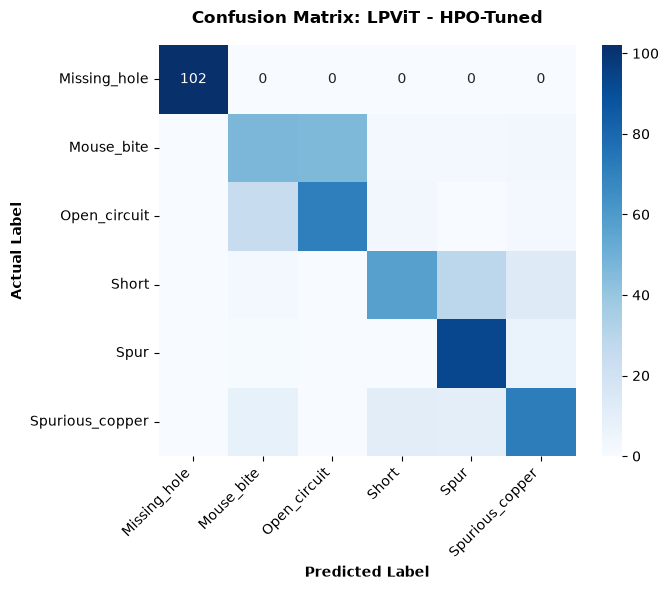

Completed: LPViT - HPO-Tuned | Test mAP: 0.7964 | Accuracy: 72.94%
Evaluating: CS-ResNet - HPO-Tuned on cuda


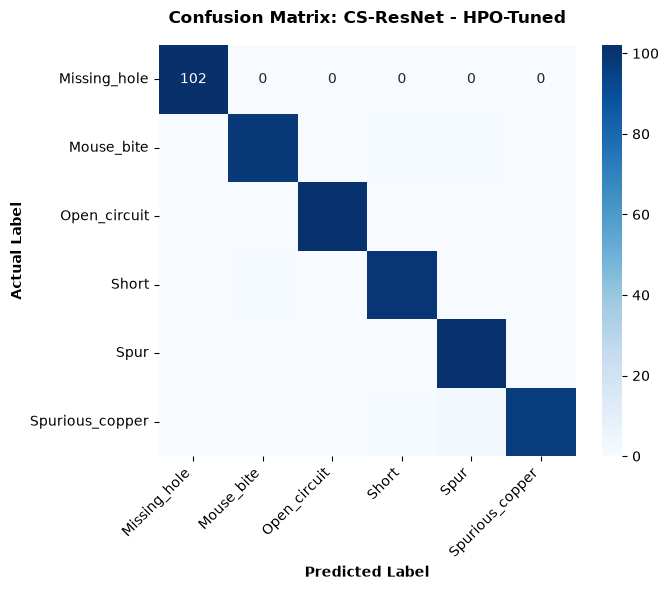

Completed: CS-ResNet - HPO-Tuned | Test mAP: 0.9996 | Accuracy: 98.84%
Evaluating: MobileNetV3 - HPO-Tuned on cuda


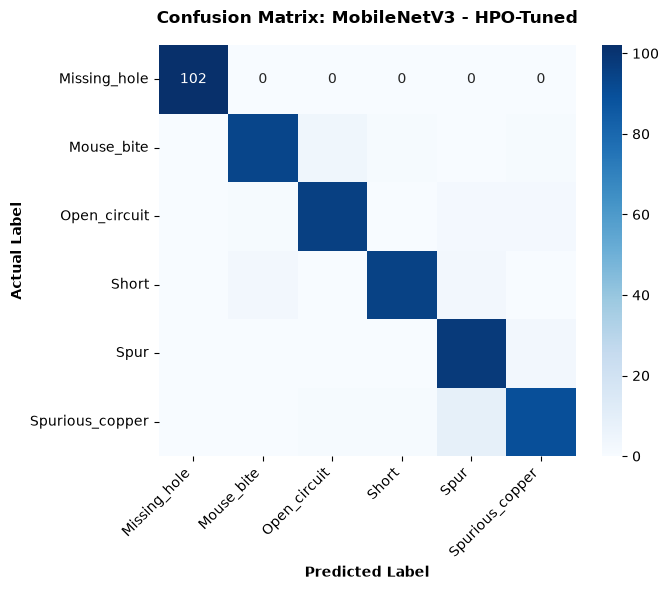

Completed: MobileNetV3 - HPO-Tuned | Test mAP: 0.9842 | Accuracy: 94.88%
Evaluating: AlexNet - HPO-Tuned on cuda


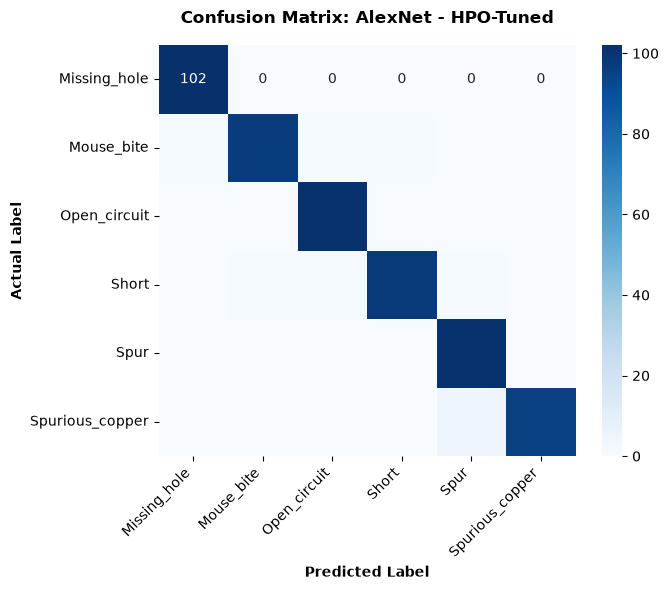

Completed: AlexNet - HPO-Tuned | Test mAP: 0.9990 | Accuracy: 98.18%
FINAL TEST BENCHMARK COMPLETED
Summary saved to: Benchmark_Results\final_benchmark_summary.csv


,Model Name,mAP (Academic),GFLOPs,Params (M),Latency Mean (ms/image),Latency Median (ms/image),Accuracy (%),"Recall (Weighted, %)","F1-Score (Macro, %)","F1-Score (Weighted, %)",Confusion Matrix,Classification Report
0,CS-ResNet - HPO-Tuned,0.9996,1.8235,11.18,0.7000,0.6626,98.84,98.84,98.84,98.84,Benchmark_Results\CS-ResNet_-_HPO-Tuned_confus...,Benchmark_Results\CS-ResNet_-_HPO-Tuned_classi...
1,AlexNet - HPO-Tuned,0.9990,0.7101,57.03,0.2972,0.2954,98.18,98.18,98.18,98.18,Benchmark_Results\AlexNet_-_HPO-Tuned_confusio...,Benchmark_Results\AlexNet_-_HPO-Tuned_classifi...
2,AlexNet - Baseline,0.9981,0.7101,57.03,0.2795,0.2801,98.18,98.18,98.19,98.19,Benchmark_Results\AlexNet_-_Baseline_confusion...,Benchmark_Results\AlexNet_-_Baseline_classific...
3,CS-ResNet - Baseline,0.9962,1.8235,11.18,0.7475,0.7191,97.36,97.36,97.33,97.33,Benchmark_Results\CS-ResNet_-_Baseline_confusi...,Benchmark_Results\CS-ResNet_-_Baseline_classif...
4,MobileNetV3 - HPO-Tuned,0.9842,0.0615,1.52,0.2125,0.2103,94.88,94.88,94.89,94.90,Benchmark_Results\MobileNetV3_-_HPO-Tuned_conf...,Benchmark_Results\MobileNetV3_-_HPO-Tuned_clas...
5,MobileNetV3 - Baseline,0.9841,0.0615,1.52,0.2194,0.2132,96.04,96.04,96.05,96.06,Benchmark_Results\MobileNetV3_-_Baseline_confu...,Benchmark_Results\MobileNetV3_-_Baseline_class...
6,LPViT - Baseline,0.8726,0.2050,1.97,0.5348,0.5341,80.53,80.53,79.83,79.90,Benchmark_Results\LPViT_-_Baseline_confusion_m...,Benchmark_Results\LPViT_-_Baseline_classificat...
7,LPViT - HPO-Tuned,0.7964,0.2050,1.97,0.6624,0.6070,72.94,72.94,72.32,72.40,Benchmark_Results\LPViT_-_HPO-Tuned_confusion_...,Benchmark_Results\LPViT_-_HPO-Tuned_classifica...


ALL EXPERIMENTS COMPLETED
Results saved in: Benchmark_Results/


,Model Name,mAP (Academic),GFLOPs,Params (M),Latency Mean (ms/image),Latency Median (ms/image),Accuracy (%),"Recall (Weighted, %)","F1-Score (Macro, %)","F1-Score (Weighted, %)",Confusion Matrix,Classification Report
0,CS-ResNet - HPO-Tuned,0.9996,1.8235,11.18,0.7000,0.6626,98.84,98.84,98.84,98.84,Benchmark_Results\CS-ResNet_-_HPO-Tuned_confus...,Benchmark_Results\CS-ResNet_-_HPO-Tuned_classi...
1,AlexNet - HPO-Tuned,0.9990,0.7101,57.03,0.2972,0.2954,98.18,98.18,98.18,98.18,Benchmark_Results\AlexNet_-_HPO-Tuned_confusio...,Benchmark_Results\AlexNet_-_HPO-Tuned_classifi...
2,AlexNet - Baseline,0.9981,0.7101,57.03,0.2795,0.2801,98.18,98.18,98.19,98.19,Benchmark_Results\AlexNet_-_Baseline_confusion...,Benchmark_Results\AlexNet_-_Baseline_classific...


In [81]:
# ==============================================================================
# FINAL EXPERIMENT EXECUTION
# ==============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Train the four default baseline models.
log_message("PHASE 1/4: TRAINING DEFAULT BASELINE MODELS")

baseline_summary_df = run_experiment(
    epochs=30,
    patience=7,
    lr=1e-4,
    mode="baseline",
)

# Run HPO using only the training and validation sets.
log_message("PHASE 2/4: RUNNING MODEL-SPECIFIC HPO")

BEST_PARAMS = execute_master_tuning(n_trials=5)

# Create four new models using the selected HPO parameters.
initialize_tuned_models(BEST_PARAMS)

# Train the four HPO-tuned models from scratch.
log_message("PHASE 3/4: TRAINING HPO-TUNED MODELS")

tuned_summary_df = run_experiment(
    epochs=30,
    patience=7,
    lr=1e-4,
    mode="tuned",
)

# Evaluate all eight trained models once on the untouched test set.
log_message("PHASE 4/4: RUNNING FINAL TEST-SET BENCHMARK")

final_evaluation_targets = [
    {"model": lpvit_sim, "device": device, "name": "LPViT - Baseline"},
    {"model": cs_resnet, "device": device, "name": "CS-ResNet - Baseline"},
    {"model": mobilenet, "device": device, "name": "MobileNetV3 - Baseline"},
    {"model": alexnet, "device": device, "name": "AlexNet - Baseline"},
    {"model": lpvit_tuned, "device": device, "name": "LPViT - HPO-Tuned"},
    {"model": cs_resnet_tuned, "device": device, "name": "CS-ResNet - HPO-Tuned"},
    {"model": mobilenet_tuned, "device": device, "name": "MobileNetV3 - HPO-Tuned"},
    {"model": alexnet_tuned, "device": device, "name": "AlexNet - HPO-Tuned"},
]

final_summary_df = benchmark_on_test_set(
    evaluation_targets=final_evaluation_targets,
    test_loader=test_loader,
)

log_message("ALL EXPERIMENTS COMPLETED")
log_message("Results saved in: Benchmark_Results/")

display(
    final_summary_df.sort_values(
        by="mAP (Academic)",
        ascending=False,
    ).head(3)
)